In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Kategori makanan: ['daging_rendang', 'ayam_goreng', 'ayam_pop', 'gulai_tambusu', 'gulai_tunjang', 'telur_dadar', 'telur_balado', 'gulai_ikan', 'dendeng_batokok']
Loading example image from: /content/drive/MyDrive/dataset_padang_food/daging_rendang/daging_rendang (32).jpg


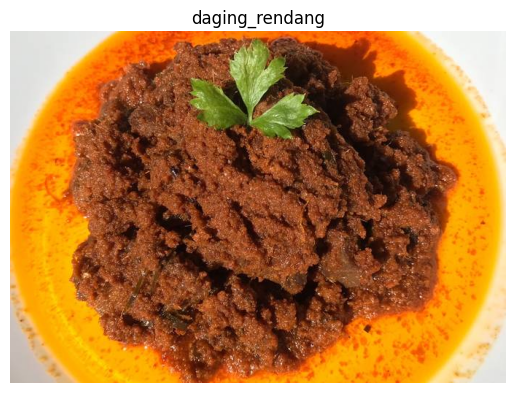

In [16]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Path dataset
dataset_path = '/content/drive/MyDrive/dataset_padang_food'

# The 'categories' variable from os.listdir(dataset_path) currently returns ['dataset_padang_food']
# We need to go one level deeper to get the actual food categories.
food_categories = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print("Kategori makanan:", food_categories)

if not food_categories:
    print("No food categories found in the dataset.")
else:
    # Pick the first food category
    chosen_category = food_categories[0]
    category_path = os.path.join(dataset_path, chosen_category)

    # List files within this category
    image_files = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]

    if not image_files:
        print(f"No image files found in category: {chosen_category}")
    else:
        # Pick the first image file
        img_filename = image_files[0]
        img_path = os.path.join(category_path, img_filename)

        print(f"Loading example image from: {img_path}")
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(chosen_category)
        plt.axis('off')
        plt.show()

In [18]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Path dataset
dataset_path = '/content/drive/MyDrive/dataset_padang_food'

# Lihat semua kategori
categories = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print("Kategori makanan Padang:", categories)
print(f"\nTotal kategori: {len(categories)}")

# Hitung jumlah gambar per kategori
for cat in categories:
    num_images = len(os.listdir(os.path.join(dataset_path, cat)))
    print(f"{cat}: {num_images} gambar")

Kategori makanan Padang: ['daging_rendang', 'ayam_goreng', 'ayam_pop', 'gulai_tambusu', 'gulai_tunjang', 'telur_dadar', 'telur_balado', 'gulai_ikan', 'dendeng_batokok']

Total kategori: 9
daging_rendang: 91 gambar
ayam_goreng: 80 gambar
ayam_pop: 79 gambar
gulai_tambusu: 86 gambar
gulai_tunjang: 90 gambar
telur_dadar: 105 gambar
telur_balado: 75 gambar
gulai_ikan: 88 gambar
dendeng_batokok: 89 gambar


In [21]:
# Install library yang diperlukan
!pip install scikit-image

# Import semua library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import cv2
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi
DATASET_PATH = '/content/drive/MyDrive/dataset_padang_food'
IMG_SIZE = (128, 128)
RANDOM_STATE = 42

print("✓ Library berhasil dimuat!")

✓ Library berhasil dimuat!


In [22]:
def load_dataset(dataset_path):
    """Memuat semua gambar dan label"""
    images = []
    labels = []
    categories = sorted([d for d in os.listdir(dataset_path)
                        if os.path.isdir(os.path.join(dataset_path, d))])

    print(f"Kategori: {categories}\n")

    for cat in categories:
        cat_path = os.path.join(dataset_path, cat)
        img_files = [f for f in os.listdir(cat_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        print(f"Loading {cat}: {len(img_files)} gambar...")

        for img_file in img_files:
            img_path = os.path.join(cat_path, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                images.append(img)
                labels.append(cat)

    print(f"\n✓ Total: {len(images)} gambar berhasil dimuat")
    return np.array(images, dtype=object), np.array(labels), categories

# Load dataset
images, labels, categories = load_dataset(DATASET_PATH)

Kategori: ['ayam_goreng', 'ayam_pop', 'daging_rendang', 'dendeng_batokok', 'gulai_ikan', 'gulai_tambusu', 'gulai_tunjang', 'telur_balado', 'telur_dadar']

Loading ayam_goreng: 80 gambar...
Loading ayam_pop: 79 gambar...
Loading daging_rendang: 91 gambar...
Loading dendeng_batokok: 89 gambar...
Loading gulai_ikan: 88 gambar...
Loading gulai_tambusu: 86 gambar...
Loading gulai_tunjang: 90 gambar...
Loading telur_balado: 75 gambar...
Loading telur_dadar: 105 gambar...

✓ Total: 783 gambar berhasil dimuat


In [23]:
def preprocess_image(img):
    """
    Preprocessing:
    1. Resize ke 128x128
    2. Gaussian Blur (mengurangi noise)
    3. Normalisasi ke range 0-1
    """
    # Resize
    img_resized = cv2.resize(img, IMG_SIZE)

    # Denoising dengan Gaussian Blur
    img_denoised = cv2.GaussianBlur(img_resized, (5, 5), 0)

    # Normalisasi
    img_normalized = img_denoised / 255.0

    return img_normalized

# Terapkan preprocessing
print("Preprocessing gambar...")
preprocessed_images = []
for i, img in enumerate(images):
    processed = preprocess_image(img)
    preprocessed_images.append(processed)
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{len(images)}")

preprocessed_images = np.array(preprocessed_images)
print(f"✓ Preprocessing selesai! Shape: {preprocessed_images.shape}")

Preprocessing gambar...
  100/783
  200/783
  300/783
  400/783
  500/783
  600/783
  700/783
✓ Preprocessing selesai! Shape: (783, 128, 128, 3)


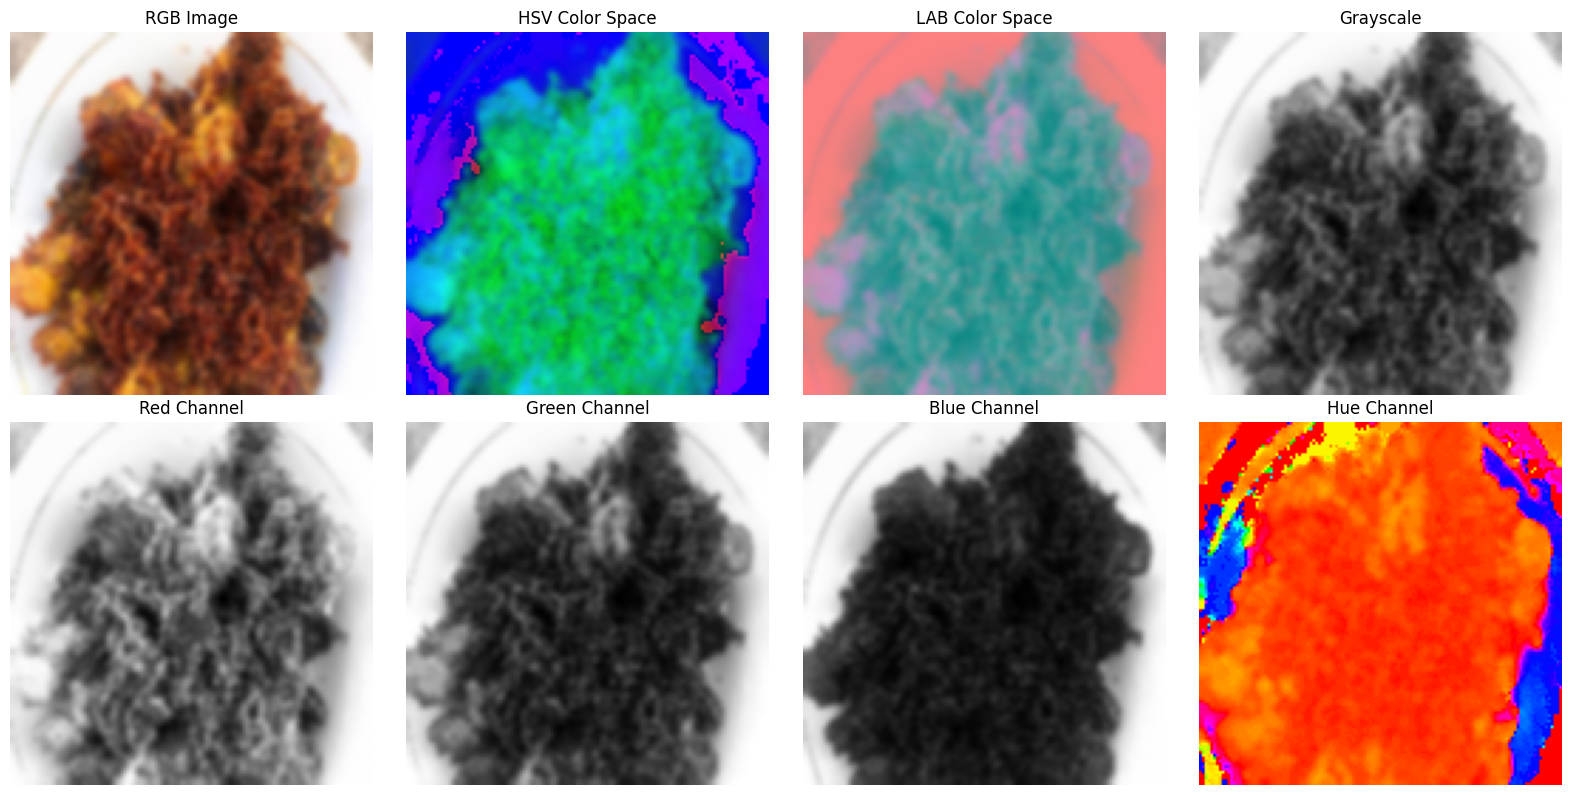

✓ Konversi color space selesai


In [24]:
def convert_color_spaces(img):
    """
    Konversi ke berbagai color space untuk analisis
    - RGB (default dari BGR)
    - HSV (Hue, Saturation, Value)
    - LAB (Lightness, A, B)
    """
    img_uint8 = (img * 255).astype(np.uint8)

    rgb = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2LAB)

    return rgb, hsv, lab

# Visualisasi color space
sample_img = preprocessed_images[0]
rgb, hsv, lab = convert_color_spaces(sample_img)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Baris 1: Gambar asli dan color spaces
axes[0, 0].imshow(rgb)
axes[0, 0].set_title('RGB Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(hsv)
axes[0, 1].set_title('HSV Color Space')
axes[0, 1].axis('off')

axes[0, 2].imshow(lab)
axes[0, 2].set_title('LAB Color Space')
axes[0, 2].axis('off')

axes[0, 3].imshow(cv2.cvtColor((sample_img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY), cmap='gray')
axes[0, 3].set_title('Grayscale')
axes[0, 3].axis('off')

# Baris 2: Channel separation RGB
for i, (color, title) in enumerate(zip(['R', 'G', 'B'], ['Red Channel', 'Green Channel', 'Blue Channel'])):
    axes[1, i].imshow(rgb[:, :, i], cmap='gray')
    axes[1, i].set_title(title)
    axes[1, i].axis('off')

# HSV Channels
axes[1, 3].imshow(hsv[:, :, 0], cmap='hsv')
axes[1, 3].set_title('Hue Channel')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

print("✓ Konversi color space selesai")

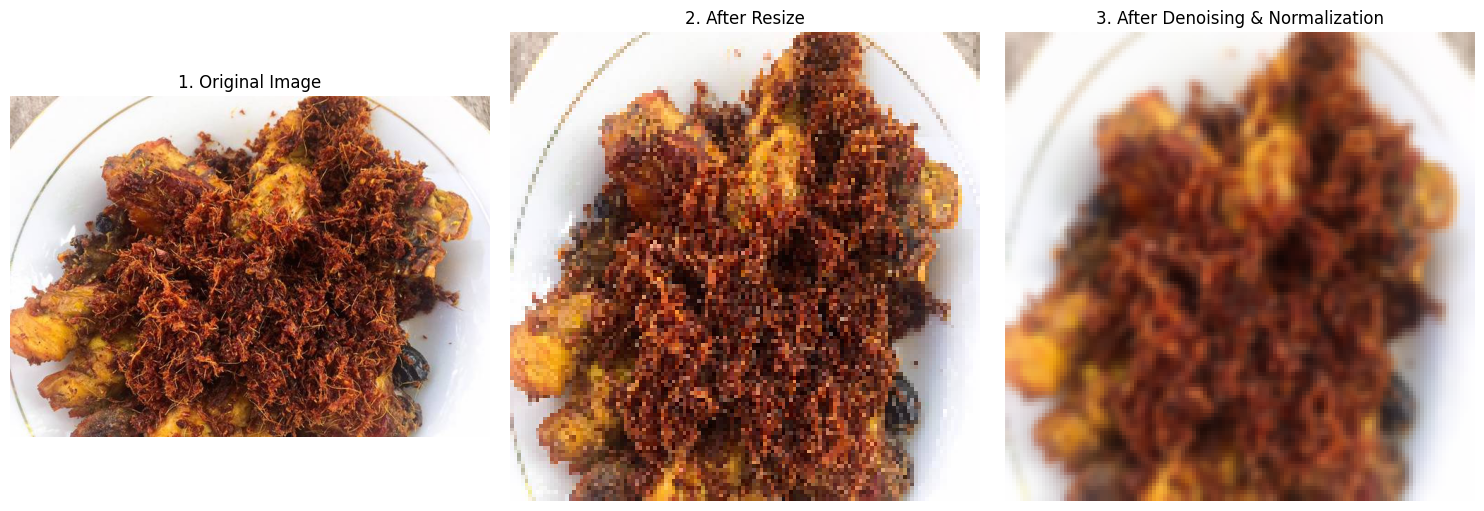

In [25]:
# Visualisasi hasil preprocessing
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sample_idx = 0
original = images[sample_idx]
processed = (preprocessed_images[sample_idx] * 255).astype(np.uint8)

axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('1. Original Image')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(cv2.resize(original, IMG_SIZE), cv2.COLOR_BGR2RGB))
axes[1].set_title('2. After Resize')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
axes[2].set_title('3. After Denoising & Normalization')
axes[2].axis('off')

plt.tight_layout()
plt.show()

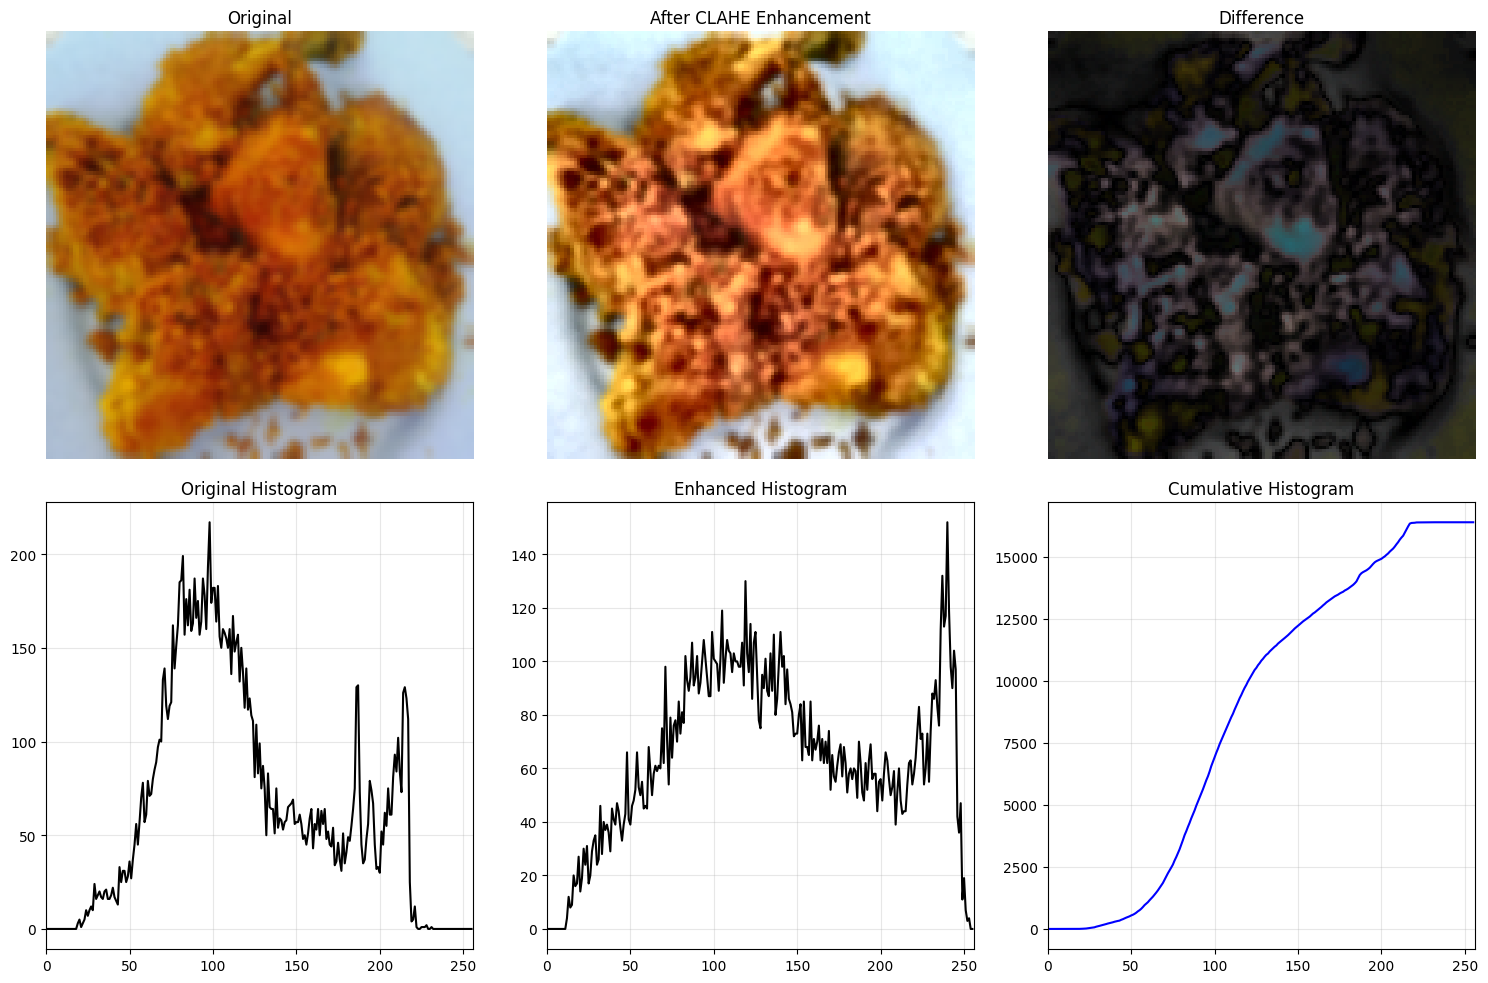

✓ Image enhancement selesai


In [26]:
def enhance_image(img):
    """
    Image Enhancement:
    - Histogram Equalization (meningkatkan kontras)
    - CLAHE (Contrast Limited Adaptive Histogram Equalization)
    """
    img_uint8 = (img * 255).astype(np.uint8)

    # Konversi ke LAB untuk enhancement
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE pada L channel
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    # Merge kembali
    enhanced_lab = cv2.merge([l_clahe, a, b])
    enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

    return enhanced / 255.0

# Visualisasi enhancement
sample_img = preprocessed_images[5]
enhanced = enhance_image(sample_img)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(cv2.cvtColor((sample_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Enhanced
axes[0, 1].imshow(cv2.cvtColor((enhanced * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('After CLAHE Enhancement')
axes[0, 1].axis('off')

# Difference
diff = np.abs(sample_img - enhanced)
axes[0, 2].imshow(cv2.cvtColor((diff * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[0, 2].set_title('Difference')
axes[0, 2].axis('off')

# Histogram comparison
for i, (img, title) in enumerate([(sample_img, 'Original Histogram'),
                                   (enhanced, 'Enhanced Histogram')]):
    img_uint8 = (img * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    axes[1, i].plot(hist, color='black')
    axes[1, i].set_title(title)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].grid(alpha=0.3)

# Cumulative histogram
gray_original = cv2.cvtColor((sample_img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
hist_cum = cv2.calcHist([gray_original], [0], None, [256], [0, 256]).cumsum()
axes[1, 2].plot(hist_cum, color='blue')
axes[1, 2].set_title('Cumulative Histogram')
axes[1, 2].set_xlim([0, 256])
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Image enhancement selesai")

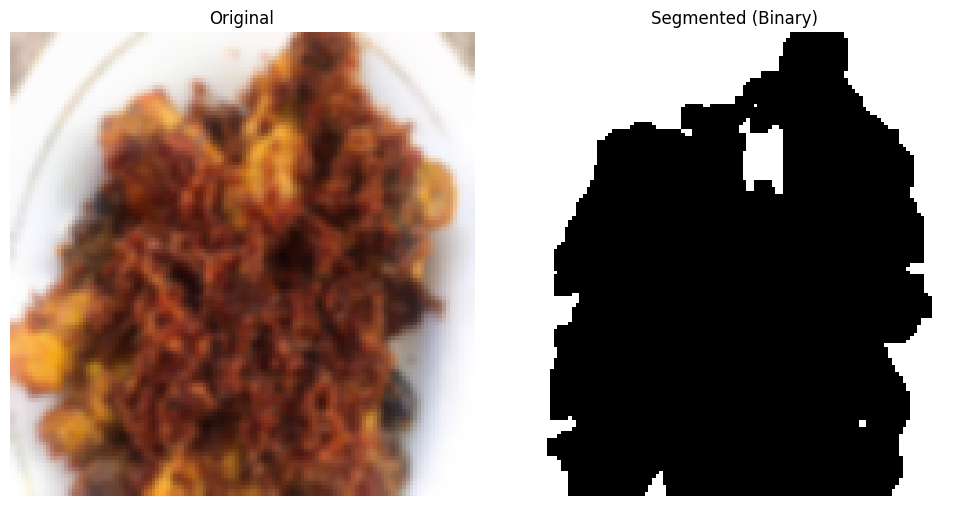

In [27]:
def segment_image(img):
    """
    Segmentasi menggunakan thresholding
    Memisahkan objek makanan dari background
    """
    # Konversi ke grayscale
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

    # Otsu thresholding
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations untuk cleanup
    kernel = np.ones((5,5), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    return cleaned

# Contoh segmentasi
sample_img = preprocessed_images[0]
segmented = segment_image(sample_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor((sample_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(segmented, cmap='gray')
axes[1].set_title('Segmented (Binary)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

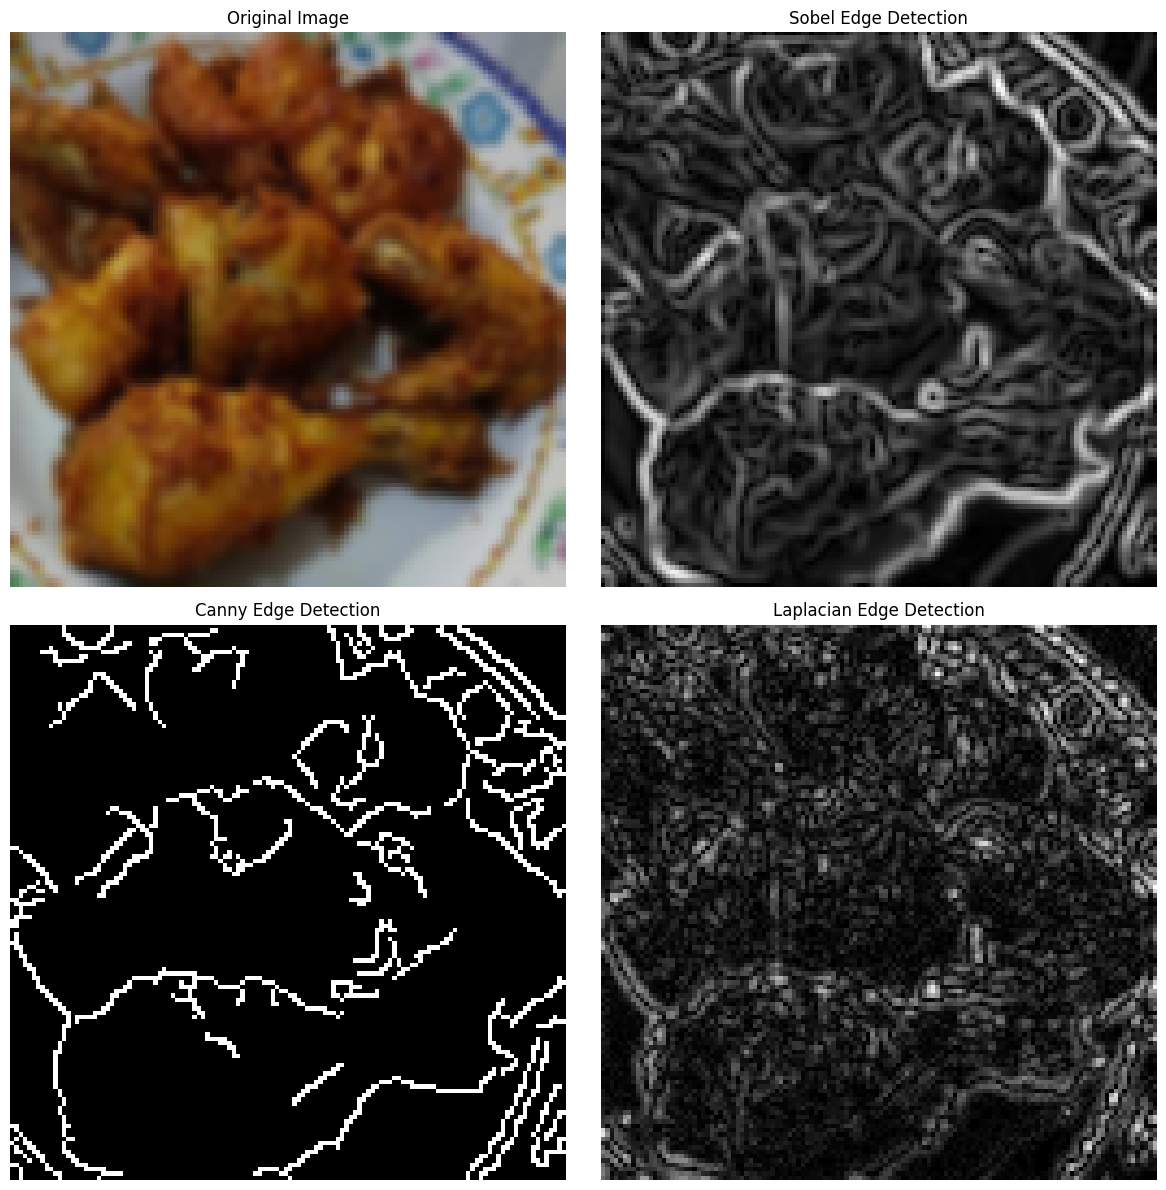

✓ Edge detection selesai


In [28]:
def detect_edges(img):
    """
    Edge Detection menggunakan berbagai metode:
    - Sobel (horizontal & vertical)
    - Canny
    - Laplacian
    """
    img_uint8 = (img * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2GRAY)

    # Sobel
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel = np.uint8(sobel / sobel.max() * 255)

    # Canny
    canny = cv2.Canny(gray, 100, 200)

    # Laplacian
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    laplacian = np.uint8(np.abs(laplacian))

    return sobel, canny, laplacian

# Visualisasi edge detection
sample_img = preprocessed_images[10]
sobel, canny, laplacian = detect_edges(sample_img)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(cv2.cvtColor((sample_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(sobel, cmap='gray')
axes[0, 1].set_title('Sobel Edge Detection')
axes[0, 1].axis('off')

axes[1, 0].imshow(canny, cmap='gray')
axes[1, 0].set_title('Canny Edge Detection')
axes[1, 0].axis('off')

axes[1, 1].imshow(laplacian, cmap='gray')
axes[1, 1].set_title('Laplacian Edge Detection')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Edge detection selesai")

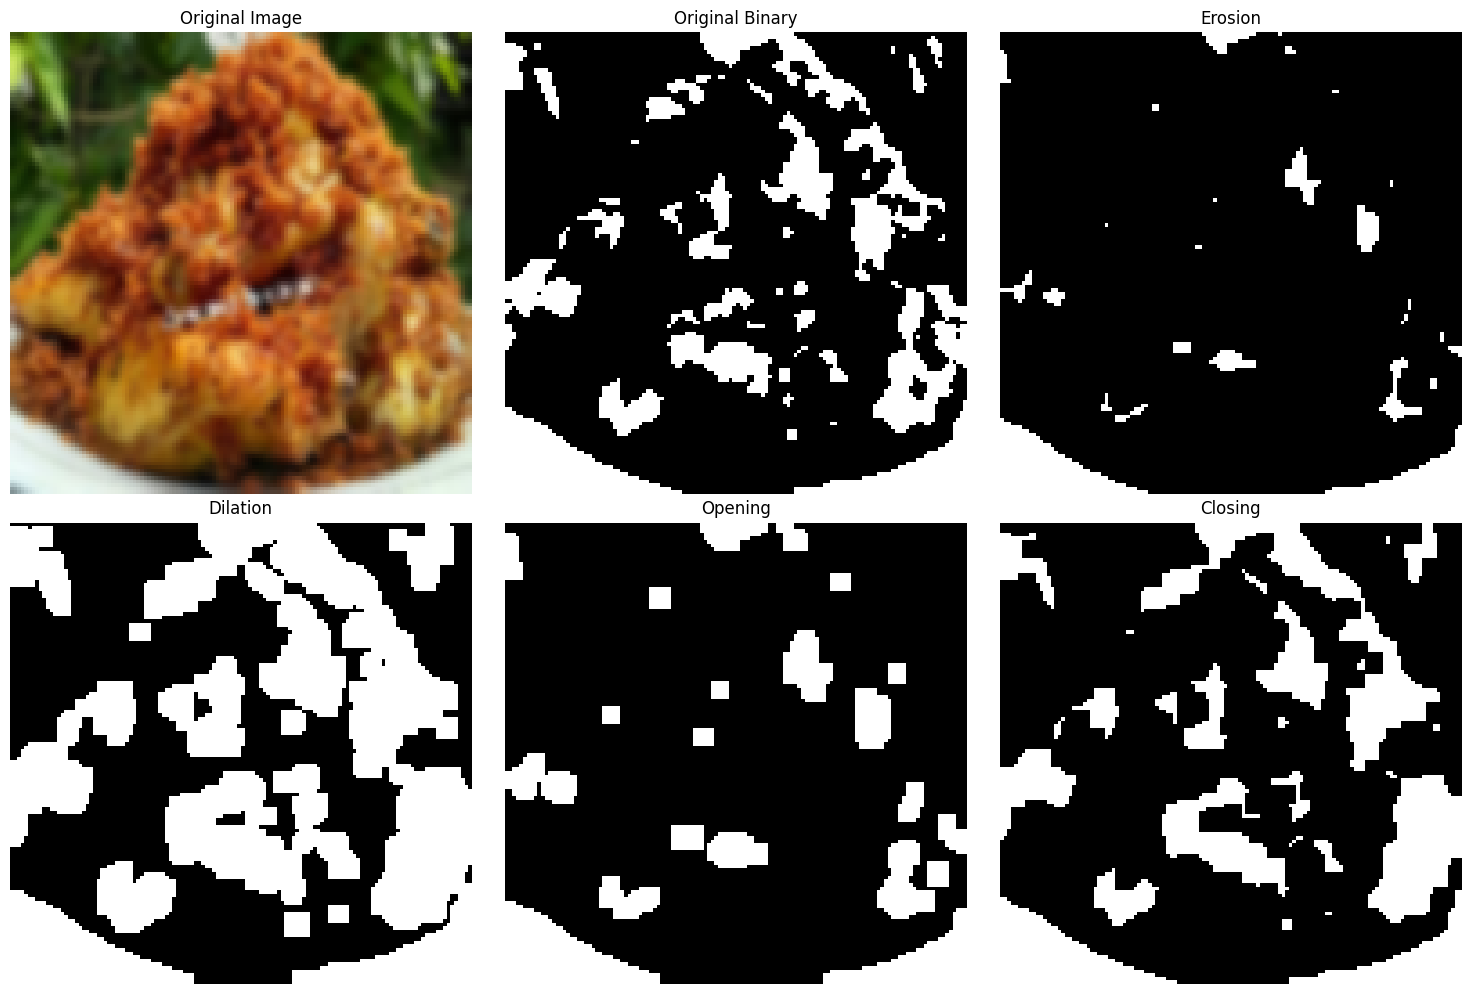

✓ Operasi morfologi selesai


In [29]:
def morphological_operations(img):
    """
    Operasi Morfologi:
    - Erosion (mengurangi objek putih)
    - Dilation (memperbesar objek putih)
    - Opening (erosi -> dilasi, menghilangkan noise)
    - Closing (dilasi -> erosi, menutup gap)
    """
    img_uint8 = (img * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    kernel = np.ones((5, 5), np.uint8)

    erosion = cv2.erode(binary, kernel, iterations=1)
    dilation = cv2.dilate(binary, kernel, iterations=1)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    return binary, erosion, dilation, opening, closing

# Visualisasi morfologi
sample_img = preprocessed_images[15]
binary, erosion, dilation, opening, closing = morphological_operations(sample_img)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

titles = ['Original Binary', 'Erosion', 'Dilation', 'Opening', 'Closing']
images_morph = [binary, erosion, dilation, opening, closing]

axes[0, 0].imshow(cv2.cvtColor((sample_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

for i, (img_morph, title) in enumerate(zip(images_morph, titles)):
    row = (i + 1) // 3
    col = (i + 1) % 3
    axes[row, col].imshow(img_morph, cmap='gray')
    axes[row, col].set_title(title)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("✓ Operasi morfologi selesai")

Analisis histogram untuk 3 kategori berbeda:

Gambar ke-0: ayam_goreng


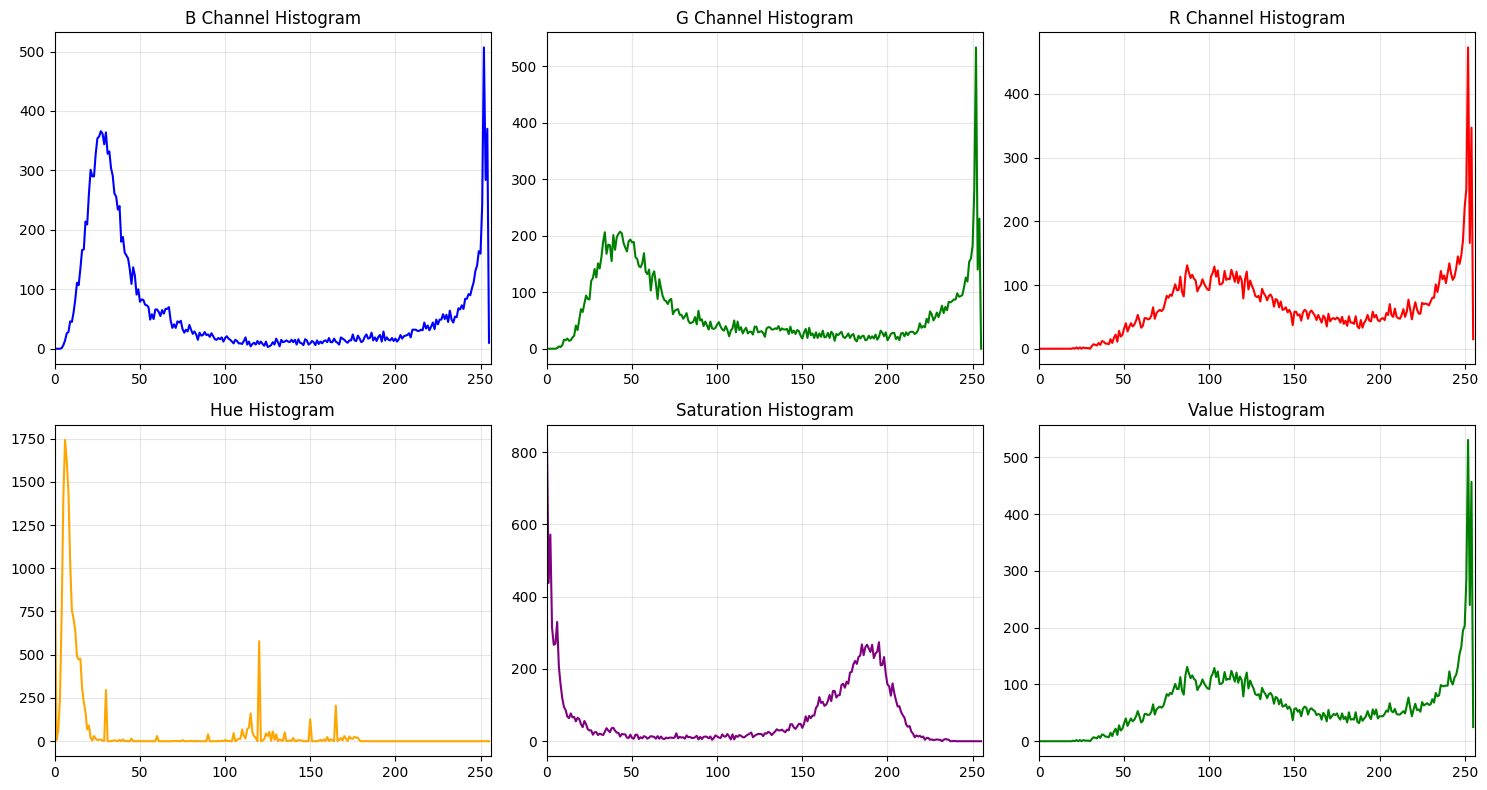


Gambar ke-100: ayam_pop


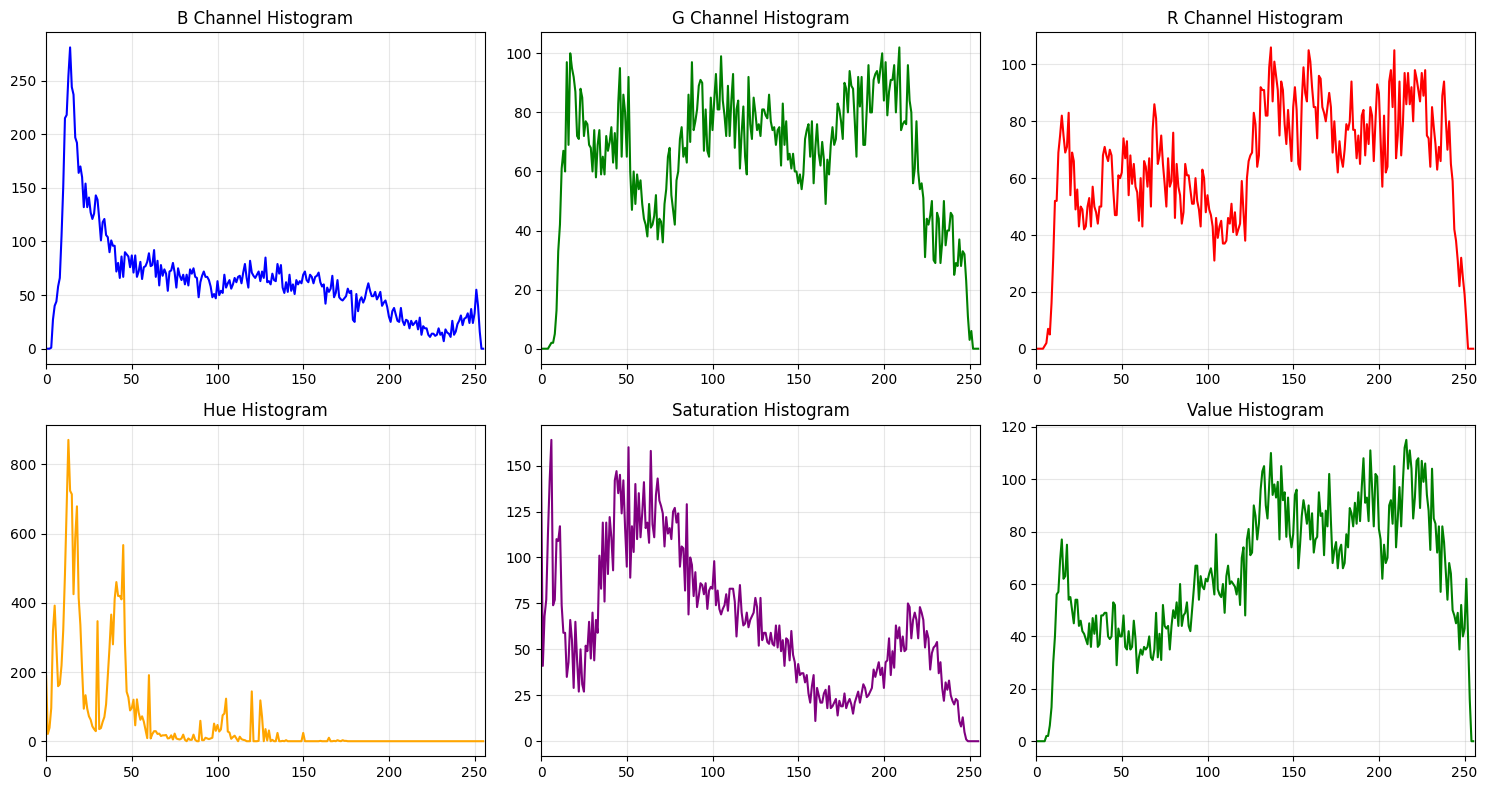


Gambar ke-200: daging_rendang


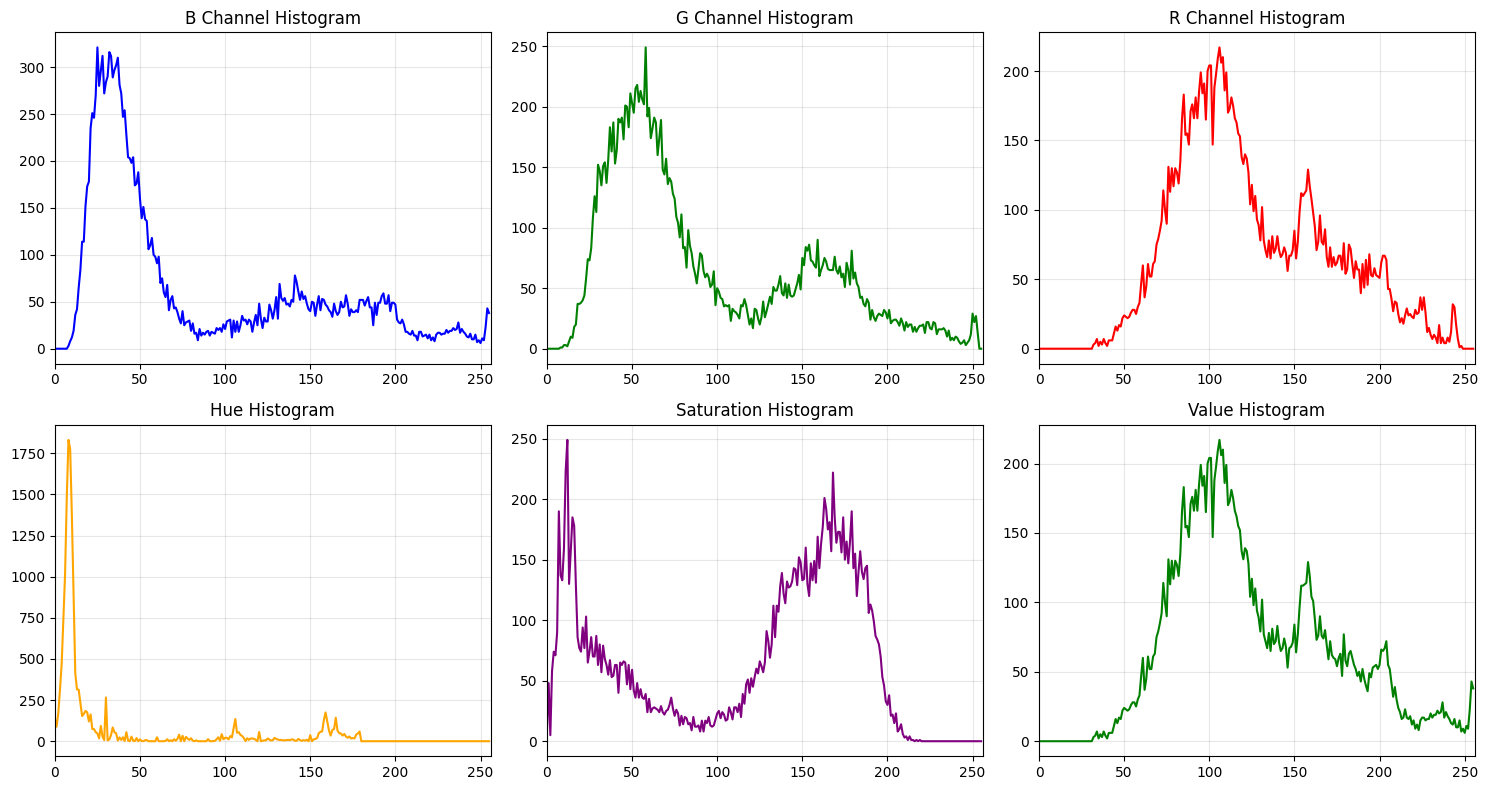

In [45]:
def analyze_histogram(img):
    """
    Analisis histogram secara detail untuk setiap channel
    """
    img_uint8 = (img * 255).astype(np.uint8)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # RGB Histogram
    colors = ('b', 'g', 'r')
    for i, color in enumerate(colors):
        hist = cv2.calcHist([img_uint8], [i], None, [256], [0, 256])
        axes[0, i].plot(hist, color=color)
        axes[0, i].set_title(f'{color.upper()} Channel Histogram')
        axes[0, i].set_xlim([0, 256])
        axes[0, i].grid(alpha=0.3)

    # HSV Histogram
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2HSV)
    hsv_names = ['Hue', 'Saturation', 'Value']
    hsv_colors = ['orange', 'purple', 'green']

    for i, (name, color) in enumerate(zip(hsv_names, hsv_colors)):
        hist = cv2.calcHist([hsv], [i], None, [256], [0, 256])
        axes[1, i].plot(hist, color=color)
        axes[1, i].set_title(f'{name} Histogram')
        axes[1, i].set_xlim([0, 256])
        axes[1, i].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Analisis histogram untuk beberapa sampel
print("Analisis histogram untuk 3 kategori berbeda:")
for i in [0, 100, 200]:
    print(f"\nGambar ke-{i}: {labels[i]}")
    analyze_histogram(preprocessed_images[i])

In [46]:
def extract_color_histogram(img):
    """
    Ekstraksi fitur warna dengan histogram
    Mengambil distribusi warna dari 3 channel (B, G, R)
    Output: 96 features (32 bins x 3 channels)
    """
    features = []
    # Ensure image is float32 for cv2.calcHist compatibility
    img_float32 = img.astype(np.float32)
    for channel in range(3):  # BGR
        hist = cv2.calcHist([img_float32], [channel], None, [32], [0, 1])
        features.extend(hist.flatten())
    return np.array(features)

# Test ekstraksi
sample_color = extract_color_histogram(preprocessed_images[0])
print(f"Jumlah fitur warna: {len(sample_color)}")

Jumlah fitur warna: 96


In [47]:
def extract_glcm_features(img):
    """
    Ekstraksi fitur tekstur dengan GLCM (Gray Level Co-occurrence Matrix)
    Properties: Contrast, Dissimilarity, Homogeneity, Energy, Correlation
    Output: 20 features (5 properties x 4 orientasi)
    """
    # Konversi ke grayscale
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

    # GLCM dengan 4 orientasi
    distances = [1]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    glcm = graycomatrix(gray, distances=distances, angles=angles,
                        levels=256, symmetric=True, normed=True)

    # Ekstrak 5 properties
    features = []
    properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    for prop in properties:
        values = graycoprops(glcm, prop).flatten()
        features.extend(values)

    return np.array(features)

# Test
sample_glcm = extract_glcm_features(preprocessed_images[0])
print(f"Jumlah fitur GLCM: {len(sample_glcm)}")

Jumlah fitur GLCM: 20


In [48]:
def extract_lbp_features(img):
    """
    Ekstraksi fitur tekstur dengan LBP (Local Binary Pattern)
    Output: 26 features (histogram LBP)
    """
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

    # Parameter LBP
    radius = 1
    n_points = 8 * radius

    # Hitung LBP
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')

    # Histogram LBP
    hist, _ = np.histogram(lbp.ravel(), bins=n_points + 2, range=(0, n_points + 2))

    # Normalisasi histogram
    hist = hist.astype('float')
    hist /= (hist.sum() + 1e-7)

    return hist

# Test
sample_lbp = extract_lbp_features(preprocessed_images[0])
print(f"Jumlah fitur LBP: {len(sample_lbp)}")

Jumlah fitur LBP: 10


In [49]:
def extract_color_moments(img):
    """
    Ekstraksi fitur warna dengan momen (mean, std dev, skewness)
    Output: 9 features (3 moments x 3 channels)
    """
    moments_features = []
    # Ensure image is in uint8 format for calculation if it's normalized
    img_uint8 = (img * 255).astype(np.uint8)

    for i in range(3):  # Iterate through B, G, R channels
        channel = img_uint8[:, :, i]
        # Calculate mean
        mean = np.mean(channel)
        # Calculate standard deviation
        std_dev = np.std(channel)
        # Calculate skewness (third central moment / (std dev)^3)
        # Avoid division by zero for std_dev
        if std_dev == 0:
            skewness = 0
        else:
            skewness = np.mean(((channel - mean) / std_dev)**3)

        moments_features.extend([mean, std_dev, skewness])
    return np.array(moments_features)

def extract_all_features(img):
    """
    Menggabungkan semua fitur:
    - Color Histogram: 96 features
    - Color Moments: 9 features
    - GLCM: 20 features
    - LBP: 26 features
    Total: 151 features
    """
    color_hist = extract_color_histogram(img)
    color_moments = extract_color_moments(img)
    glcm = extract_glcm_features(img)
    lbp = extract_lbp_features(img)

    return np.concatenate([color_hist, color_moments, glcm, lbp])

# Ekstraksi fitur dari semua gambar
print("Ekstraksi fitur dari semua gambar...")
features_list = []

for i, img in enumerate(preprocessed_images):
    features = extract_all_features(img)
    features_list.append(features)

    if (i+1) % 100 == 0:
        print(f"  Progress: {i+1}/{len(preprocessed_images)}")

X = np.array(features_list)
print(f"\n✓ Ekstraksi fitur selesai!")
print(f"  Shape fitur: {X.shape}")
print(f"  Total fitur per gambar: {X.shape[1]}")

Ekstraksi fitur dari semua gambar...
  Progress: 100/783
  Progress: 200/783
  Progress: 300/783
  Progress: 400/783
  Progress: 500/783
  Progress: 600/783
  Progress: 700/783

✓ Ekstraksi fitur selesai!
  Shape fitur: (783, 135)
  Total fitur per gambar: 135


In [50]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

print("Mapping kategori ke angka:")
for i, cat in enumerate(label_encoder.classes_):
    print(f"  {i}: {cat}")

# Split data: 80% training, 20% temporary (for validation and testing)
X_train, X_temp, y_train, y_temp, train_images, temp_images = train_test_split(
    X, y, images, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Split temporary data: 50% validation, 50% testing (10% masing-masing dari data awal)
X_val, X_test, y_val, y_test, val_images, test_images = train_test_split(
    X_temp, y_temp, temp_images, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"
✓ Data splitting selesai!")
print(f"  Training: {len(X_train)} gambar")
print(f"  Validation: {len(X_val)} gambar")
print(f"  Testing: {len(X_test)} gambar")


Mapping kategori ke angka:
  0: ayam_goreng
  1: ayam_pop
  2: daging_rendang
  3: dendeng_batokok
  4: gulai_ikan
  5: gulai_tambusu
  6: gulai_tunjang
  7: telur_balado
  8: telur_dadar

✓ Data splitting selesai!
  Training: 626 gambar
  Validation: 78 gambar
  Testing: 79 gambar


In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ Normalisasi fitur selesai!")
print(f"  Mean sebelum scaling (Train): {X_train[0][:5]}")
print(f"  Mean setelah scaling (Train): {X_train_scaled[0][:5]}")
print(f"  Mean sebelum scaling (Validation): {X_val[0][:5]}")
print(f"  Mean setelah scaling (Validation): {X_val_scaled[0][:5]}")

✓ Normalisasi fitur selesai!
  Mean sebelum scaling (Train): [ 782. 1874. 1506. 1326. 1238.]
  Mean setelah scaling (Train): [-0.25383132  0.19496217  0.06361283  0.01927028  0.09573338]
  Mean sebelum scaling (Validation): [ 23.  74. 128. 168. 292.]
  Mean setelah scaling (Validation): [-0.65072828 -1.00456266 -1.37123214 -1.54013821 -1.27478649]


In [69]:
from sklearn.neighbors import KNeighborsClassifier

# Membuat model KNN
# n_neighbors = jumlah tetangga terdekat (bisa diubah: 3, 5, 7, dll)
knn_model = KNeighborsClassifier(
    n_neighbors=8,           # K=5 (bisa dicoba nilai lain)
    weights='distance',       # Bobot berdasarkan jarak
    metric='euclidean'        # Metrik jarak Euclidean
)

print("Training model KNN...")
knn_model.fit(X_train_scaled, y_train)
print("✓ Training selesai!")

Training model KNN...
✓ Training selesai!


In [70]:
# Prediksi pada data testing
y_pred = knn_model.predict(X_test_scaled)

# Hitung akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*50}")
print(f"HASIL EVALUASI MODEL KNN")
print(f"{'='*50}")
print(f"Akurasi: {accuracy*100:.2f}%\n")

# Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


HASIL EVALUASI MODEL KNN
Akurasi: 62.03%

Classification Report:
                 precision    recall  f1-score   support

    ayam_goreng       0.50      0.50      0.50         8
       ayam_pop       0.71      0.62      0.67         8
 daging_rendang       0.67      0.67      0.67         9
dendeng_batokok       0.50      0.67      0.57         9
     gulai_ikan       0.67      0.67      0.67         9
  gulai_tambusu       0.50      0.56      0.53         9
  gulai_tunjang       0.78      0.78      0.78         9
   telur_balado       1.00      0.43      0.60         7
    telur_dadar       0.58      0.64      0.61        11

       accuracy                           0.62        79
      macro avg       0.66      0.61      0.62        79
   weighted avg       0.65      0.62      0.62        79



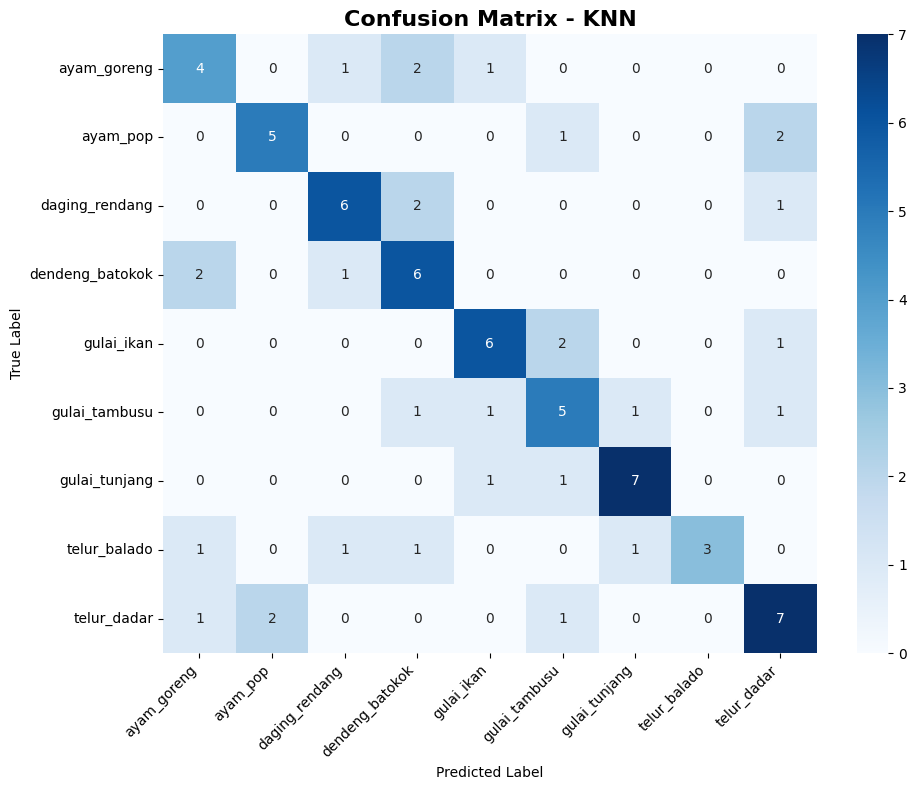


Akurasi per Kelas:
  ayam_goreng: 50.00%
  ayam_pop: 62.50%
  daging_rendang: 66.67%
  dendeng_batokok: 66.67%
  gulai_ikan: 66.67%
  gulai_tambusu: 55.56%
  gulai_tunjang: 77.78%
  telur_balado: 42.86%
  telur_dadar: 63.64%


In [71]:
# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - KNN', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Hitung akurasi per kelas
print("\nAkurasi per Kelas:")
for i, cat in enumerate(label_encoder.classes_):
    class_accuracy = cm[i, i] / cm[i].sum() * 100
    print(f"  {cat}: {class_accuracy:.2f}%")

Mencari nilai K optimal...
  K=1: Accuracy=50.63%
  K=2: Accuracy=50.63%
  K=3: Accuracy=51.90%
  K=4: Accuracy=60.76%
  K=5: Accuracy=59.49%
  K=6: Accuracy=58.23%
  K=7: Accuracy=56.96%
  K=8: Accuracy=62.03%
  K=9: Accuracy=59.49%
  K=10: Accuracy=58.23%
  K=11: Accuracy=55.70%
  K=12: Accuracy=53.16%
  K=13: Accuracy=53.16%
  K=14: Accuracy=58.23%
  K=15: Accuracy=59.49%
  K=16: Accuracy=56.96%
  K=17: Accuracy=55.70%
  K=18: Accuracy=51.90%
  K=19: Accuracy=55.70%
  K=20: Accuracy=55.70%


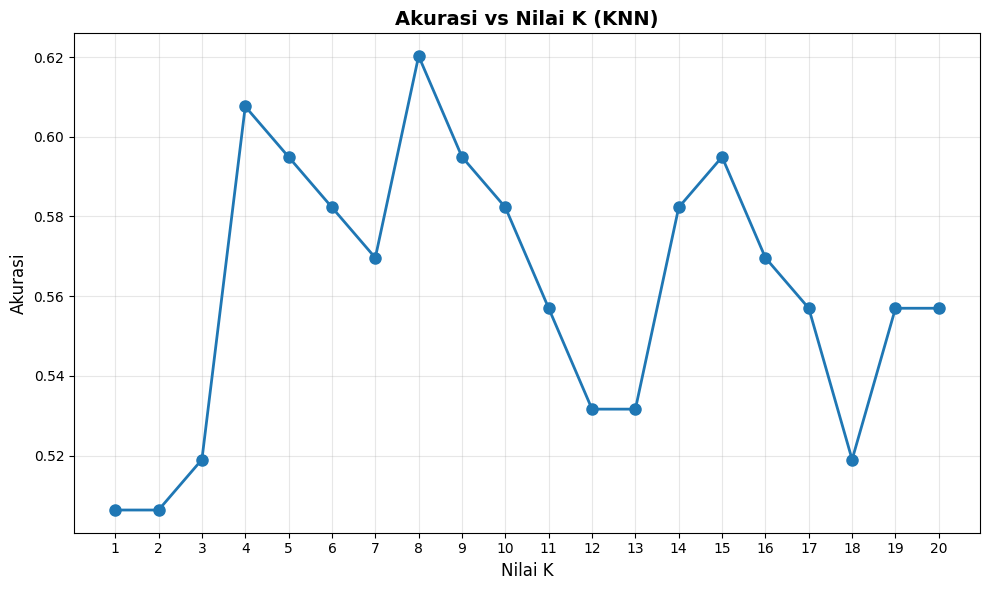


✓ K Optimal: 8 dengan akurasi 62.03%


In [72]:
# Coba berbagai nilai K untuk menemukan yang terbaik
k_values = range(1, 21)
accuracies = []

print("Mencari nilai K optimal...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"  K={k}: Accuracy={acc*100:.2f}%")

# Plot hasil
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('Nilai K', fontsize=12)
plt.ylabel('Akurasi', fontsize=12)
plt.title('Akurasi vs Nilai K (KNN)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\n✓ K Optimal: {best_k} dengan akurasi {best_acc*100:.2f}%")

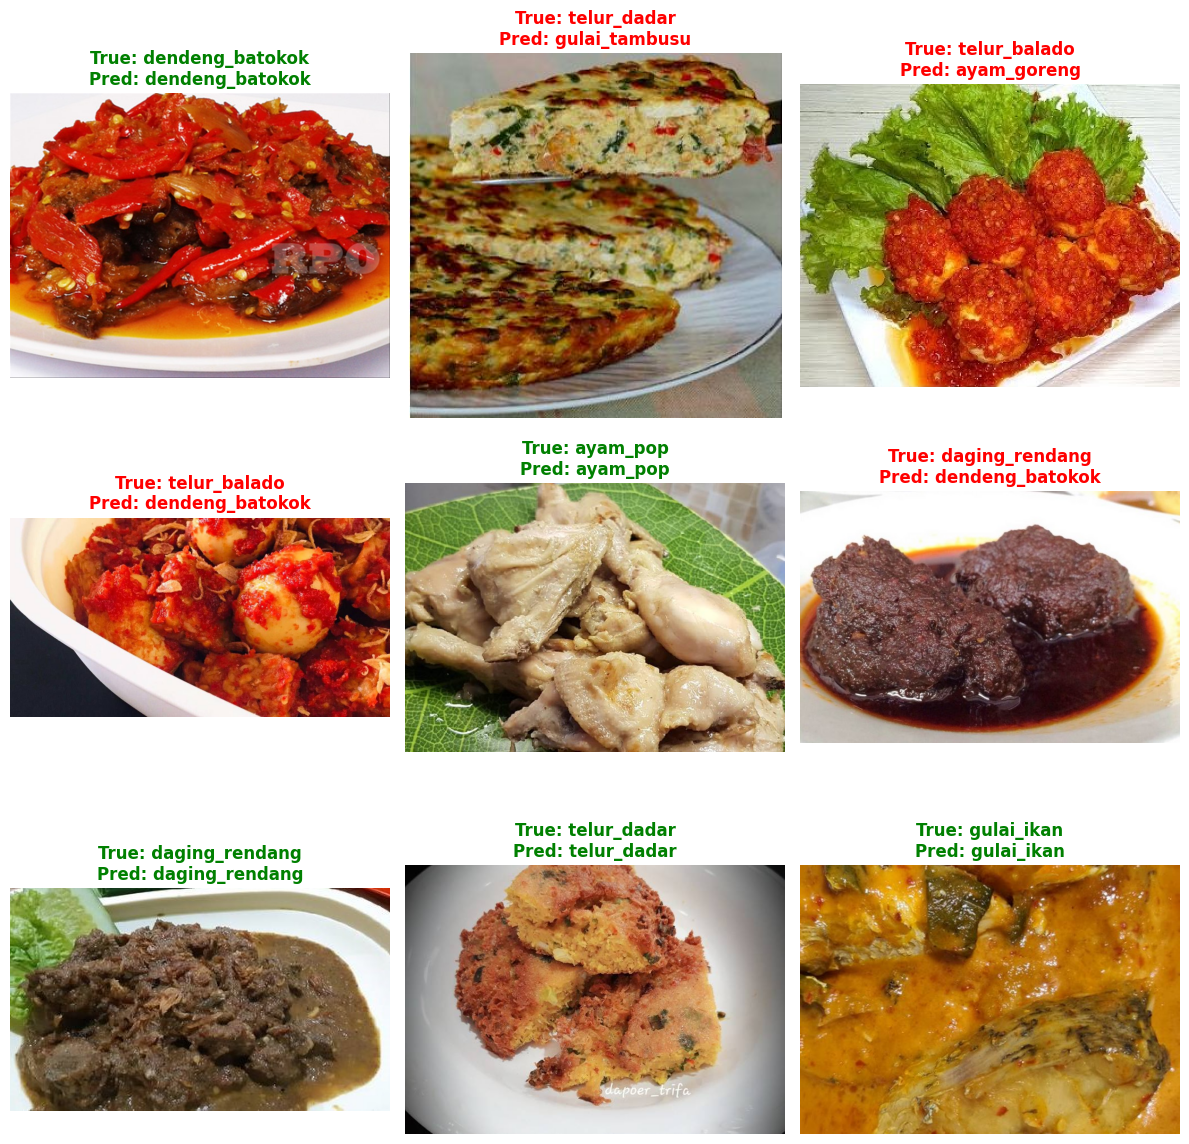

In [74]:
# Visualisasi beberapa hasil prediksi
num_samples = 9
indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, idx in enumerate(indices):
    # Ambil gambar asli dari index test set
    original_idx = np.where((X == X_test[idx]).all(axis=1))[0][0]
    img = images[original_idx]

    true_label = label_encoder.classes_[y_test[idx]]
    pred_label = label_encoder.classes_[y_pred[idx]]

    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    # Warna hijau jika benar, merah jika salah
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}',
                     color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [75]:
import pickle

# Simpan model dan scaler
with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("✓ Model berhasil disimpan!")
print("  - knn_model.pkl")
print("  - scaler.pkl")
print("  - label_encoder.pkl")

✓ Model berhasil disimpan!
  - knn_model.pkl
  - scaler.pkl
  - label_encoder.pkl
